In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os

def load(filename):
    """Carrega un CSV del projecte gestionant la capçalera sep=,"""
    path = filename
    with open(path, encoding='utf-8-sig') as f:
        first = f.readline().strip()
    skip = 1 if first == 'sep=,' else 0
    return pd.read_csv(path, skiprows=skip, encoding='utf-8-sig', low_memory=False)



# CONSIDERACIONS INICIALS AMB ELS CSV's

1. `Precipitation_data` i `Intrensiy_Precipitation` són idèntics (mateix contingut, diferent nom de fitxer).

In [17]:
p_v1 = load('../data/Intrensiy_Precipitation-data-as-joinbyfield-2026-02-12 14_22_19.csv')
p_v2 = load('../data/Precipitation-data-as-joinbyfield-2026-02-12 14_21_47.csv')

print(f'Shape Intrensiy: {p_v1.shape}')
print(f'Shape Precipitation_data: {p_v2.shape}')
print(f'Columnes iguals: {list(p_v1.columns) == list(p_v2.columns)}')
print(f'Contingut idèntic: {p_v1.equals(p_v2)}')
print()
print('Mostra Intrensiy:')
display(p_v1.dropna().head(3))
print('Mostra Precipitation_data:')
display(p_v2.dropna().head(3))

Shape Intrensiy: (605682, 3)
Shape Precipitation_data: (605682, 3)
Columnes iguals: True
Contingut idèntic: True

Mostra Intrensiy:


,Time,Precipitation Intensity,Precipitation Intensity.1
125954,2025-08-03 00:00:00,0 mm/h,0 mm/h
125957,2025-08-03 00:01:30,0 mm/h,0 mm/h
125959,2025-08-03 00:02:30,0 mm/h,0 mm/h


Mostra Precipitation_data:


,Time,Precipitation Intensity,Precipitation Intensity.1
125954,2025-08-03 00:00:00,0 mm/h,0 mm/h
125957,2025-08-03 00:01:30,0 mm/h,0 mm/h
125959,2025-08-03 00:02:30,0 mm/h,0 mm/h


CONCLUSIÓ: Els dos fitxers són IDÈNTICS, excloem Intrensiy_Precipitation i mantenim Precipitation per l'anàlisi.
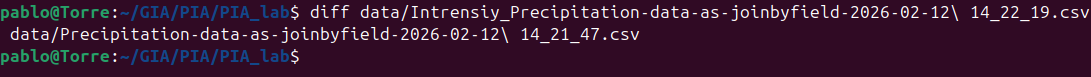

---
2. `Precipitation_quantity (Total  Difference cumulative sum)` és un subconjunt de `Precipitation (Total  Difference cumulative sum)`. Mateixos valors, però `Precipitation (Total  Difference cumulative sum)` té més registres recents.

In [24]:
c_v1 = load('../data/Precipitation_quantity_Precipitation (Total  Difference cumulative sum)-data-2026-02-12 09_05_15.csv')
c_v2 = load('../data/Precipitation (Total  Difference cumulative sum)-data-2026-02-12 14_23_21.csv')

print(f'Shape Precipitation_quantity: {c_v1.shape}      Rang: {c_v1["Time"].min()} -> {c_v1["Time"].max()}')
print(f'Shape Precipitation: {c_v2.shape}               Rang: {c_v2["Time"].min()} -> {c_v2["Time"].max()}')
print(f'Registres extra a Precipitation: {len(c_v2) - len(c_v1)}')

# Verificar que tots els timestamps de v1 estan a v2 amb el mateix valor
merged = pd.merge(c_v1, c_v2, on='Time', suffixes=('_v1', '_v2'))
col_v1 = 'Precipitation Difference (Cumulative sum)_v1'
col_v2 = 'Precipitation Difference (Cumulative sum)_v2'
identics = (merged[col_v1] == merged[col_v2]).sum()
print(f'\nRegistres comuns: {len(merged):,}')
print(f'Valors idèntics en timestamps comuns: {identics:,} / {len(merged):,} ({100*identics/len(merged):.1f}%)')

Shape Precipitation_quantity: (605011, 2)      Rang: 2025-06-16 11:55:30 -> 2026-02-12 08:44:30
Shape Precipitation: (605682, 2)               Rang: 2025-06-16 11:55:30 -> 2026-02-12 14:20:00
Registres extra a Precipitation: 671

Registres comuns: 605,011
Valors idèntics en timestamps comuns: 605,011 / 605,011 (100.0%)


Veiem que ambdós comencen les lectures a les 11:55:30 del 2025-06-16, tenen les mateixes lectures, però un csv té l'última lectura el 2026-02-12 08:44:30 i l'altre el 2026-02-12 14:20:00

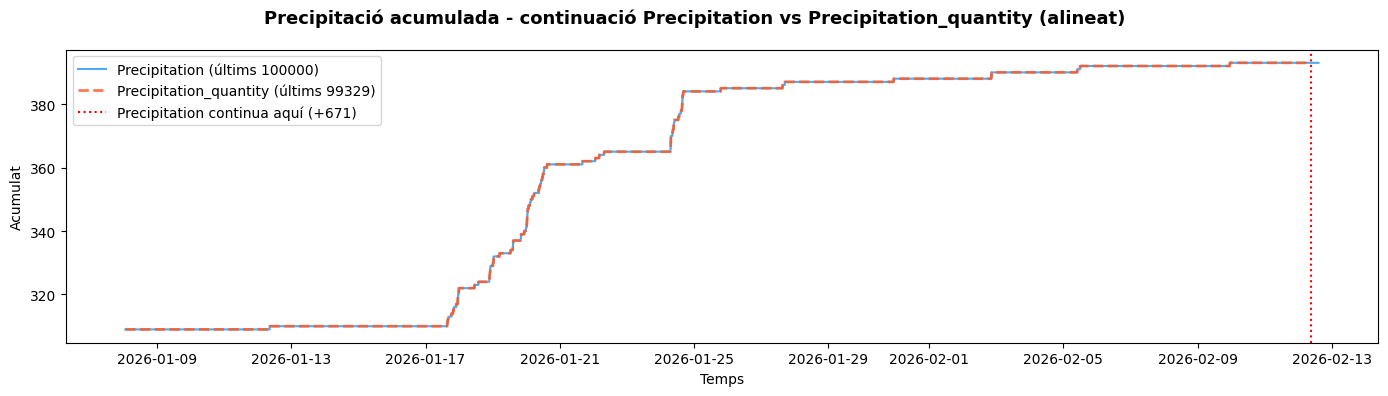

In [34]:
n_v2 = 100000
extra = 671
n_v1 = n_v2 - extra

v2_plot = c_v2.tail(n_v2)
v1_plot = c_v1.tail(n_v1)


fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Precipitació acumulada - continuació Precipitation vs Precipitation_quantity (alineat)', fontsize=13, fontweight='bold')


vals_v2 = v2_plot['Precipitation Difference (Cumulative sum)'] \
    .str.extract(r'([\d\.]+)')[0].astype(float)

times_v2 = pd.to_datetime(v2_plot['Time'])
ax.plot(times_v2, vals_v2,
        color='#2196F3', lw=1.5, label=f'Precipitation (últims {n_v2})', alpha=0.8)


vals_v1 = v1_plot['Precipitation Difference (Cumulative sum)'] \
    .str.extract(r'([\d\.]+)')[0].astype(float)

times_v1 = pd.to_datetime(v1_plot['Time'])
ax.plot(times_v1, vals_v1,
        color='#FF5722', lw=2.0, ls='--', label=f'Precipitation_quantity (últims {n_v1})', alpha=0.8)


ax.axvline(times_v1.max(),
           color='red', ls=':', lw=1.5, label='Precipitation continua aquí (+671)')

ax.set_xlabel('Temps')
ax.set_ylabel('Acumulat')
ax.legend()

plt.tight_layout()
plt.show()

CONCLUSIÓ: Ens quedem únicament amb el fitxer Precipitation (Total  Difference cumulative sum) perquè és el que té més registres.

---
3. `Precipitation_type_-data-2026-02-12 09_01_21.csv` i `Precipitation_type_-data-2026-02-12 09_02_48.csv` mesuren el tipus de precipitació però amb codificació diferent (simple vs WMO wawa).

In [53]:
t_simple = load('../data/Precipitation_type_-data-2026-02-12 09_01_21.csv')
t_wmo    = load('../data/Precipitation_type_-data-2026-02-12 09_02_48.csv')

print(f'Shape simple: {t_simple.shape}         Columna: {list(t_simple.columns)}    Rang: {t_simple["Time"].min()} -> {t_simple["Time"].max()}')
print(f'Shape WMO:    {t_wmo.shape}         Columna: {list(t_wmo.columns)}    Rang: {t_wmo["Time"].min()} -> {t_wmo["Time"].max()}')

print('\n')
print(t_simple['Precipitation Type'].value_counts().to_string())

print('\n')
print(t_wmo['Precipitation WMO_wawa'].value_counts().to_string())

Shape simple: (605010, 2)         Columna: ['Time', 'Precipitation Type']    Rang: 2025-06-16 11:55:30 -> 2026-02-12 08:44:00
Shape WMO:    (605011, 2)         Columna: ['Time', 'Precipitation WMO_wawa']    Rang: 2025-06-16 11:55:30 -> 2026-02-12 08:44:30


Precipitation Type
No precipitation               571201
Liquid precipitation (rain)     33347
Solid precipitation (snow)        371
sleet                              91


Precipitation WMO_wawa
No significant weather             569404
rain not freezing, slight           25234
drizzle, not freezing, slight        3244
rain, not freezing, moderate         3114
drizzle + rain, slight               1339
drizzle, not freezing, moderate      1264
rain, not freezing, heavy             713
snow, slight                          539
rain/drizzle + snow, slight           116
snow, moderate                         44


In [57]:
t_wmo = t_wmo.iloc[:-1]

# Join per timestamp
merged = t_simple.merge(t_wmo, on='Time', how='inner')
print(f"Registres coincidents: {len(merged):,}  |  "
      f"sense parella simple: {len(t_simple)-len(merged):,}  |  "
      f"sense parella WMO: {len(t_wmo)-len(merged):,}\n")

# Timestamps que estan a simple però NO a WMO
nomes_simple = t_simple[~t_simple['Time'].isin(t_wmo['Time'])]
print("Només a simple:")
print(nomes_simple)

# Timestamps que estan a WMO però NO a simple
nomes_wmo = t_wmo[~t_wmo['Time'].isin(t_simple['Time'])]
print("\nNomés a WMO:")
print(nomes_wmo)

ct = pd.crosstab(
    merged['Precipitation Type'],
    merged['Precipitation WMO_wawa'],
    margins=True, margins_name='TOTAL'
)
ct


Registres coincidents: 605,001  |  sense parella simple: 9  |  sense parella WMO: 6

Només a simple:
                       Time Precipitation Type
73689   2025-07-15 00:09:31   No precipitation
143323  2025-08-11 05:38:59   No precipitation
219808  2025-09-23 11:45:28   No precipitation
236698  2025-10-04 20:19:06   No precipitation
236728  2025-10-04 20:51:30   No precipitation
570503  2026-01-31 05:14:08   No precipitation
605007  2026-02-12 08:43:00   No precipitation
605008  2026-02-12 08:43:30   No precipitation
605009  2026-02-12 08:44:00   No precipitation

Només a WMO:
                       Time  Precipitation WMO_wawa
73689   2025-07-15 00:09:32  No significant weather
143323  2025-08-11 05:42:52  No significant weather
219808  2025-09-23 11:45:32  No significant weather
236698  2025-10-04 20:19:02  No significant weather
236728  2025-10-04 20:51:31  No significant weather
570503  2026-01-31 05:14:09  No significant weather


Precipitation WMO_wawa,No significant weather,"drizzle + rain, slight","drizzle, not freezing, moderate","drizzle, not freezing, slight","rain not freezing, slight","rain, not freezing, heavy","rain, not freezing, moderate","rain/drizzle + snow, slight","snow, moderate","snow, slight",TOTAL
Precipitation Type,,,,,,,,,,,
Liquid precipitation (rain),3609,1055,1180,1713,21887,691,3062,99,0,51,33347
No precipitation,565741,284,84,1527,3315,22,50,0,0,169,571192
Solid precipitation (snow),35,0,0,4,29,0,1,12,23,267,371
sleet,9,0,0,0,3,0,1,5,21,52,91
TOTAL,569394,1339,1264,3244,25234,713,3114,116,44,539,605001


CONCLUSIÓ: La taula mostra que, en la gran majoria de registres, ambdós sensors coincideixen: 565,744 mesures s'etiqueten com a "No precipitation" / "No significant weather" 
i 21,887 com a pluja lleugera. Tanmateix, s'observen discrepàncies puntuals: per exemple, 3,609 registres 
classificats com "Liquid precipitation" al sensor simple apareixen com "No significant weather" al WMO_wawa, 
i casos on un sensor detecta neu mentre l'altre registra pluja no congelant (51 i 29 registres respectivament). 
Això suggereix diferències de sensibilitat i llindar de detecció entre els dos instruments.

Per a l'anàlisi exploratòria optarem pel dataset simple (`Precipitation Type`), donat que les seves 
quatre categories ofereixen una llegibilitat i interpretabilitat directa. No obstant, no descartem el 
dataset WMO_wawa per a anàlisis que requereixin major granularitat (distingir, per exemple, 
plugim de pluja moderada o nevada lleugera de moderada). En qualsevol cas, abans d'usar el WMO_wawa 
de forma definitiva caldrà resoldre les discrepàncies identificades i els 8 registres sense parella, 
per garantir la coherència temporal entre ambdós datasets.

---
4. `PV_panel_temperatures` i `PV_panel_temperatures_Section_S1` són dos exports del mateix sensor S1 amb freqüències de mostreig diferents i cobertura diferent de seccions.

In [59]:
pv_all = load('../data/PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv')
pv_s1  = load('../data/PV_PV panel temperatures_ Section S1-data-as-joinbyfield-2026-02-12 14_19_00.csv')

print(f'Shape PV_all:  {pv_all.shape}    Columnes: {list(pv_all.columns)}')
print(f'Shape PV_S1:   {pv_s1.shape}     Columnes: {list(pv_s1.columns)}')
print()
print(f'Rang PV_all:   {pv_all["Time"].min()} -> {pv_all["Time"].max()}')
print(f'Rang PV_S1:    {pv_s1["Time"].min()} -> {pv_s1["Time"].max()}')
print()
print(f'Freqüència PV_all (h): {pv_all["Time"].apply(pd.Timestamp).diff().dt.total_seconds().div(3600).mode()[0]:.0f}h')
print(f'Freqüència PV_S1  (h): {pv_s1["Time"].apply(pd.Timestamp).diff().dt.total_seconds().div(3600).mode()[0]:.0f}h')

print()
print('Mostra PV_all:')
display(pv_all.dropna().head(3))
print('Mostra PV_S1:')
display(pv_s1.dropna().head(3))

Shape PV_all:  (1753, 9)    Columnes: ['Time', 'S1 T1', 'S1 T2', 'S1 T3', 'S1 T4', 'S2 T1', 'S2 T2', 'S2 T3', 'S2 T4']
Shape PV_S1:   (1170, 5)     Columnes: ['Time', 'T1', 'T2', 'T3', 'T4']

Rang PV_all:   2025-05-12 04:00:00 -> 2025-10-05 04:00:00
Rang PV_S1:    2025-05-12 02:00:00 -> 2025-10-05 05:00:00

Freqüència PV_all (h): 2h
Freqüència PV_S1  (h): 3h

Mostra PV_all:


,Time,S1 T1,S1 T2,S1 T3,S1 T4,S2 T1,S2 T2,S2 T3,S2 T4
449,2025-06-18 14:00:00,51.5 °C,49.4 °C,50.1 °C,50.1 °C,47.5 °C,46.1 °C,48.7 °C,49.4 °C
450,2025-06-18 16:00:00,49.3 °C,47.1 °C,48.0 °C,47.8 °C,45.7 °C,44.3 °C,47.2 °C,48.0 °C
451,2025-06-18 18:00:00,39.9 °C,38.0 °C,38.6 °C,38.4 °C,37.5 °C,36.4 °C,38.3 °C,38.7 °C


Mostra PV_S1:


,Time,T1,T2,T3,T4
300,2025-06-18 14:00:00,51.0 °C,48.9 °C,49.6 °C,49.6 °C
301,2025-06-18 17:00:00,42.6 °C,40.7 °C,41.4 °C,41.1 °C
302,2025-06-18 20:00:00,23.6 °C,23.5 °C,23.6 °C,23.5 °C


In [60]:
def parse_num(series):
    return series.str.extract(r'([\d\.]+)')[0].astype(float)

pv_all['Time'] = pd.to_datetime(pv_all['Time'])
pv_s1['Time']  = pd.to_datetime(pv_s1['Time'])

pv_all_num = pv_all.copy()
pv_s1_num  = pv_s1.copy()
for col in ['S1 T1','S1 T2','S1 T3','S1 T4']:
    pv_all_num[col] = parse_num(pv_all[col])
for col in ['T1','T2','T3','T4']:
    pv_s1_num[col] = parse_num(pv_s1[col])

merged = pd.merge(
    pv_all_num[['Time','S1 T1','S1 T2','S1 T3','S1 T4']],
    pv_s1_num[['Time','T1','T2','T3','T4']],
    on='Time', how='inner'
).dropna()

print(f'Timestamps comuns: {len(merged):,}')
for i in range(1, 5):
    diff = (merged[f'S1 T{i}'] - merged[f'T{i}']).abs()
    print(f'  S1 T{i} vs T{i}:  diferència mitjana = {diff.mean():.2f}°C,  màxima = {diff.max():.2f}°C')

Timestamps comuns: 412
  S1 T1 vs T1:  diferència mitjana = 1.14°C,  màxima = 7.10°C
  S1 T2 vs T2:  diferència mitjana = 1.07°C,  màxima = 6.40°C
  S1 T3 vs T3:  diferència mitjana = 1.09°C,  màxima = 6.80°C
  S1 T4 vs T4:  diferència mitjana = 1.10°C,  màxima = 6.90°C


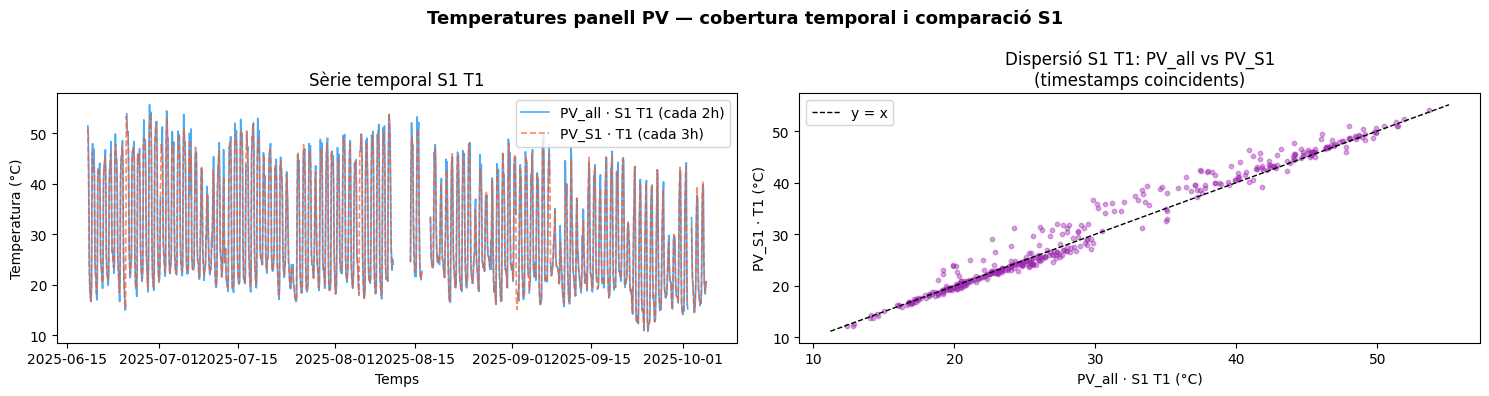

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Temperatures panell PV — cobertura temporal i comparació S1', fontsize=13, fontweight='bold')

# — Esquerra: sèrie temporal S1 T1 dels dos fitxers
ax = axes[0]
ax.plot(pv_all_num['Time'], pv_all_num['S1 T1'],
        color='#2196F3', lw=1.2, alpha=0.8, label='PV_all · S1 T1 (cada 2h)')
ax.plot(pv_s1_num['Time'], pv_s1_num['T1'],
        color='#FF5722', lw=1.2, alpha=0.7, ls='--', label='PV_S1 · T1 (cada 3h)')
ax.set_title('Sèrie temporal S1 T1')
ax.set_xlabel('Temps')
ax.set_ylabel('Temperatura (°C)')
ax.legend()

# — Dreta: scatter S1 T1 en timestamps coincidents
ax2 = axes[1]
ax2.scatter(merged['S1 T1'], merged['T1'],
            alpha=0.4, s=10, color='#9C27B0')
lims = [merged[['S1 T1','T1']].min().min() - 1,
        merged[['S1 T1','T1']].max().max() + 1]
ax2.plot(lims, lims, 'k--', lw=1, label='y = x')
ax2.set_title('Dispersió S1 T1: PV_all vs PV_S1\n(timestamps coincidents)')
ax2.set_xlabel('PV_all · S1 T1 (°C)')
ax2.set_ylabel('PV_S1 · T1 (°C)')
ax2.legend()

plt.tight_layout()
plt.show()

CONCLUSIÓ: Els dos fitxers cobreixen el mateix rang temporal (2025-05-12 -> 2025-10-05) però amb granularitats i abasts diferents: `PV_all` mostra les dues seccions (S1 i S2) amb una mostra cada 2h (1.753 registres), mentre que `PV_S1` conté únicament la secció S1 amb una mostra cada 3h (1.170 registres). Els valors de S1 no coincideixen exactament (diferència mitjana ~1 °C) perquè cada fitxer va ser exportat amb una resolució temporal diferent (2h vs 3h): l'eina de monitoratge agrega les lectures dins de cada interval i, com que els intervals no coincideixen, els valors resultants difereixen lleugerament.

Ens quedem amb `PV_all` perquè és el dataset més complet: inclou S1 i S2, té major resolució temporal (2h vs 3h) i, per tant, més registres vàlids. `PV_S1` queda descartat per ser redundant i menys informatiu.

## SUBCONJUNT DE CSV PER A L'ANÀLISI

1) AIR_AIR Temperatures (ALL)-data-as-joinbyfield-2026-02-12 08_56_48.csv
   - Temperatures de l'aire de diversos sensors/posicions (act/avg/max/min i punts S1/S2/R1) al llarg del temps.

2) AIR_ePAR (all parameters)-data-as-joinbyfield-2026-02-12 09_00_37.csv
   - Mesures ePAR (radiació PAR) de diversos sensors, amb canals cal_out, immersed i versions 16bit.

3) PV_Irradiance-data-as-joinbyfield-2026-02-12 14_17_50.csv
   - Irradiància dels panells FV (GPOA i albedo) per seccions S1 i S2.

4) PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv
   - Temperatures dels panells FV (T1..T4) per secció S1 i S2.

5) Precipitation (Total  Difference cumulative sum)-data-2026-02-12 14_23_21.csv
   - Precipitació acumulada (suma acumulada de la diferència).

6) Precipitation-data-as-joinbyfield-2026-02-12 14_21_47.csv
   - Intensitat de precipitació (mm/h) en el temps (dues sèries d'intensitat).

7) Precipitation_type_-data-2026-02-12 09_01_21.csv
   - Tipus de precipitació categòric (p. ex. "No precipitation", pluja, neu, etc.).

8) SOIL_Temperature-data-as-joinbyfield-2026-02-12 08_54_57.csv
   - Temperatura del sòl en múltiples sondes/posicions (R1, S1, S2).

9) SOIL_VWC-data-as-joinbyfield-2026-02-12 08_57_18.csv
   - Humitat volumètrica del sòl (VWC) en múltiples sondes/posicions.

10) Tracking angles-data-as-joinbyfield-2026-02-12 14_24_26.csv
    - Angle real dels trackers solars (tracker_M01 ... tracker_M10).

11) Wind direction-data-2026-02-12 14_25_08.csv
    - Direcció predominant del vent.

12) Wind speed-data-2026-02-12 09_05_40.csv
    - Velocitat del vent (km/h).
